In [ ]:
!pip install pydataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 57.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939415 sha256=973e5365f62ad45760bdc4253a38f5e1e335787d1aad3db4a0345fe93896cae8
  Stored in directory: /root/.cache/pip/wheels/4c/82/ad/f04abc617222b10438b1285ab9b5cfaecd180c10a7c81cff54
Successfully built pydataset


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from pydataset import data

initiated datasets repo at: /root/.pydataset/


In [ ]:
pima = data('Pima.tr')

In [ ]:
pima

,npreg,glu,bp,skin,bmi,ped,age,type
1,5,86,68,28,30.2,0.364,24,No
2,7,195,70,33,25.1,0.163,55,Yes
3,5,77,82,41,35.8,0.156,35,No
4,0,165,76,43,47.9,0.259,26,No
5,0,107,60,25,26.4,0.133,23,No
...,...,...,...,...,...,...,...,...
196,2,141,58,34,25.4,0.699,24,No
197,7,129,68,49,38.5,0.439,43,Yes
198,0,106,70,37,39.4,0.605,22,No
199,1,118,58,36,33.3,0.261,23,No


In [ ]:
x = pima[['skin']]
y = pima['bmi']

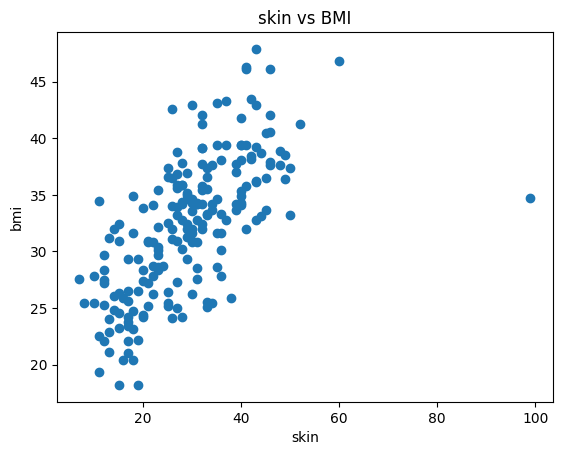

In [ ]:
plt.scatter(x,y)
plt.xlabel('skin')
plt.ylabel('bmi')
plt.title('skin vs BMI')
plt.show()

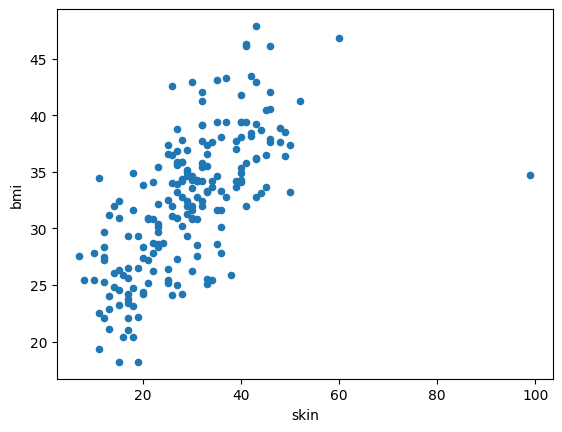

In [ ]:
pima.plot(kind = 'scatter', x = 'skin', y = 'bmi')
plt.show()

Step 2

In [ ]:
X = pima[['skin']] # x independent variable, y dependent variable, that's is the reason behind double bracket
y = pima['bmi']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

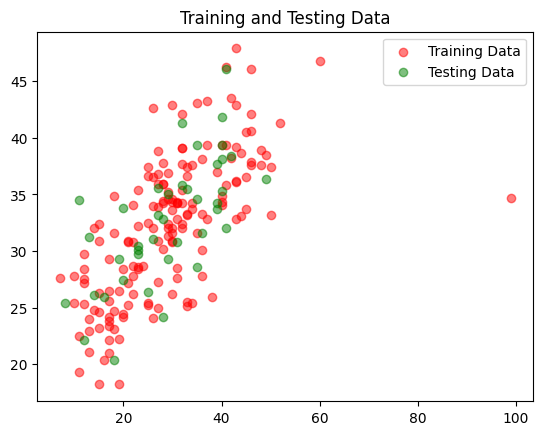

In [ ]:
plt.scatter(X_train, y_train, label = 'Training Data', color = 'r', alpha= 0.5)
plt.scatter(X_test, y_test, label = 'Testing Data', color = 'g', alpha= 0.5)
plt.legend()
plt.title('Training and Testing Data')
# plt.xlabel('skin')
# plt.ylabel('bmi')
plt.show()

Create the Model from the Training and Testing Data

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

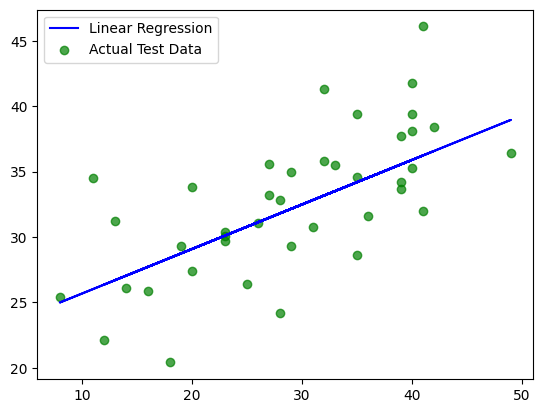

In [ ]:
plt.plot(X_test, y_pred, label = 'Linear Regression', color= 'b')
plt.scatter(X_test, y_test, label = 'Actual Test Data', color = 'g', alpha = .7)

plt.legend()
#plt.title('Linear Regression')
plt.show()

In [ ]:
model.predict(np.array([[50]]))[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(39.29175968210983)

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')

Mean Squared Error: 16.37059983983064
Root Mean Squared Error: 4.046059791924811


Multiple Linear Regression

In [ ]:
wine = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/winequality-red.csv', sep= ";")
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
wine = wine[['pH','alcohol','quality']]
wine.head()

,pH,alcohol,quality
0,3.51,9.4,5
1,3.20,9.8,5
2,3.26,9.8,5
3,3.16,9.8,6
4,3.51,9.4,5


In [ ]:
X = wine.drop('quality', axis =1)
y = wine['quality'].values

X



,pH,alcohol
0,3.51,9.4
1,3.20,9.8
2,3.26,9.8
3,3.16,9.8
4,3.51,9.4
...,...,...
1594,3.45,10.5
1595,3.52,11.2
1596,3.42,11.0
1597,3.57,10.2


In [ ]:
y

array([5, 5, 5, ..., 6, 5, 6])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(X_test.columns)

Index(['pH', 'alcohol'], dtype='object')


In [ ]:
x1 = X_test['pH']
x2 = X_test['alcohol']
y_actual = y_test
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


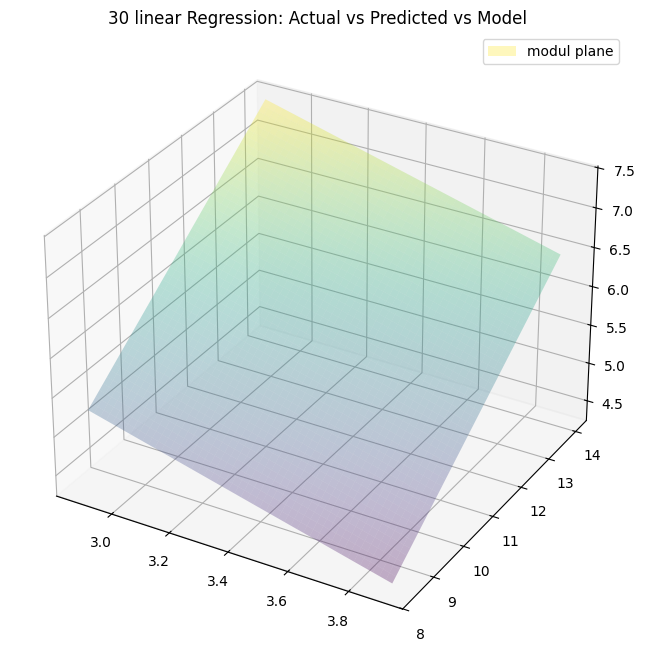

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (12,8))
ax = fig.add_subplot(111, projection='3d')

x1_range = np.linspace(min(x1), max(x1), 50)
x2_range = np.linspace(min(x2), max(x2), 50)
x1_mesh,x2_mesh = np.meshgrid(x1_range, x2_range)
X_mesh = np.c_[x1_mesh.ravel(), x2_mesh.ravel()]

y_mesh = model.predict(X_mesh).reshape(x1_mesh.shape)

ax.plot_surface(x1_mesh, x2_mesh, y_mesh, alpha = 0.3, cmap = 'viridis', label = 'modul plane')
ax.set_title('30 linear Regression: Actual vs Predicted vs Model')

ax.legend()
plt.show()

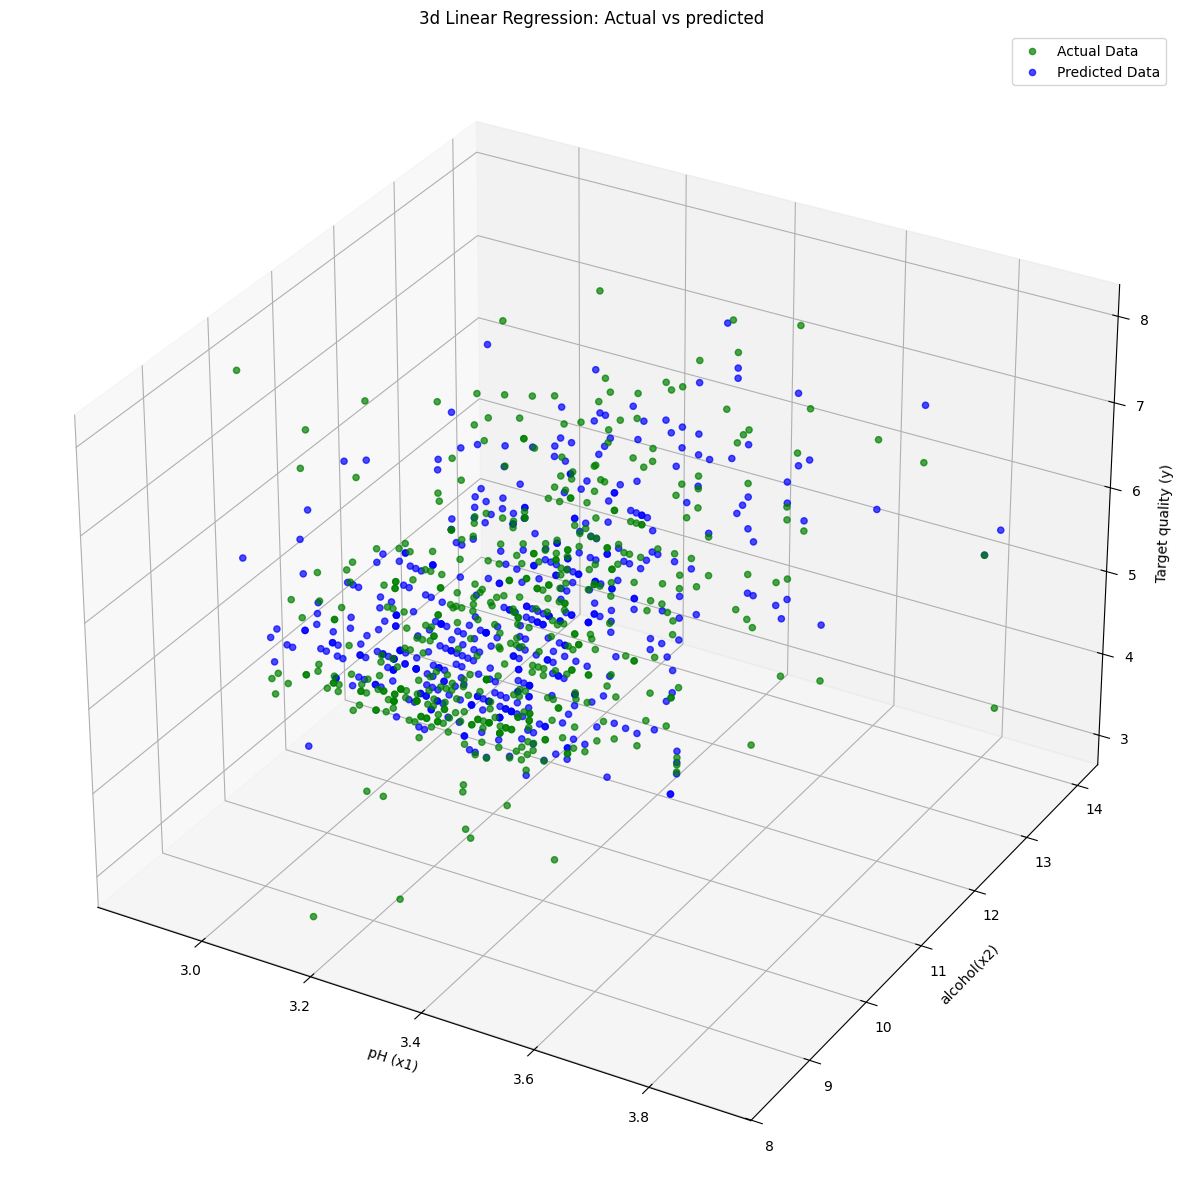

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
x1 = X_test['pH']
x2 = X_test['alcohol']
y_actual = y_test
y_pred = model.predict(X_test)
fig = plt.figure(figsize=(15,20))
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(x1, x2, y_actual, color = 'g', alpha = 0.7, label = 'Actual Data')
ax.scatter(x1, x2, y_pred, color = 'b', alpha = 0.7, label = 'Predicted Data')

ax.set_xlabel('pH (x1)')
ax.set_ylabel('alcohol(x2)')
ax.set_zlabel('Target quality (y)')
ax.set_title('3d Linear Regression: Actual vs predicted')
ax.legend()
plt.show()